# Домашняя работа 3

## Задача 1
тест для проверки равномерности распределения.

In [2]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
def serial_test(sample, k=10):
    expected = (len(sample)//2)/(k*k)
    pairs = [(sample[2*i],sample[2*i+1]) for i in range(len(sample)//2)]
    observed = np.zeros((k,k),dtype=int)
    for x,y in pairs:
        i = min(int(x*k),k-1)
        j = min(int(y*k),k-1)
        observed[i,j] += 1
    f_obs = observed.reshape(-1)
    f_exp = np.full(k*k,expected)
    return stats.chisquare(f_obs,f_exp)
def rng(m=2**32,a=1103515245,c=12345):
    rng.current = (a*rng.current+c)%m
    return rng.current/m
rng.current = 1
samples = [rng() for _ in range(1000)]
res = serial_test(samples,10)
print(f"Статистика: {res.statistic}")
print(f"p-значение: {res.pvalue}")
if res.pvalue > 0.05:
    print("Не отвергаем H0: распределение равномерное")
else:
    print("Отвергаем H0: распределение НЕ равномерное")

Статистика: 114.39999999999999
p-значение: 0.1380441495447643
Не отвергаем H0: распределение равномерное


## Задача 3
rng bad rng good


In [5]:
def rng_bad(m=2**31,a=65539,c=0):
    rng_bad.current = (a*rng_bad.current+c)%m
    return rng_bad.current/m
def rng_good(m=2**32,a=1103515245,c=12345):
    rng_good.current = (a*rng_good.current+c)%m
    return rng_good.current/m
def serial_test_3d(sample,k=12):
    expected = (len(sample)//3)/(k**3)
    triples = [(sample[3*i],sample[3*i+1],sample[3*i+2]) for i in range(len(sample)//3)]
    observed = np.zeros((k,k,k),dtype=int)
    for x,y,z in triples:
        i = min(int(x*k),k-1)
        j = min(int(y*k),k-1)
        l = min(int(z*k),k-1)
        observed[i,j,l] += 1
    f_obs = observed.reshape(-1)
    f_exp = np.full(k**3,expected)
    return stats.chisquare(f_obs,f_exp)
rng_bad.current = 1
rng_good.current = 1
bad = [rng_bad() for _ in range(30000)]
good = [rng_good() for _ in range(30000)]
res_bad = serial_test_3d(bad,12)
res_good = serial_test_3d(good,12)
print(f"rng_bad: статистика={res_bad.statistic:.2f}, p-значение={res_bad.pvalue:.2e}")
if res_bad.pvalue > 0.05:
    print("rng_bad: не отвергаем H0 -распределение равномерное")
else:
    print("rng_bad: отвергаем H0 - распределениеНЕ равномерное")
print(f"rng_good: статистика={res_good.statistic:.2f}, p-значение={res_good.pvalue:.2f}")
if res_good.pvalue > 0.05:
    print("rng_good: не отвергаем H0 -распределениеравномерное")
else:
    print("rng_good:отвергаем H0 - распределение НЕ равномерное")

rng_bad: статистика=2398.40, p-значение=8.06e-25
rng_bad: отвергаем H0 - распределениеНЕ равномерное
rng_good: статистика=1643.61, p-значение=0.92
rng_good: не отвергаем H0 -распределениеравномерное


## Задача 4
дискретное распределение на цифрах 0-9 с заданными весами

Количество каждой цифры в выборке:
Цифра 0: 51 раз
Цифра 1: 156 раз
Цифра 2: 81 раз
Цифра 3: 127 раз
Цифра 4: 156 раз
Цифра 5: 269 раз
Цифра 6: 56 раз
Цифра 7: 11 раз
Цифра 9: 93 раз


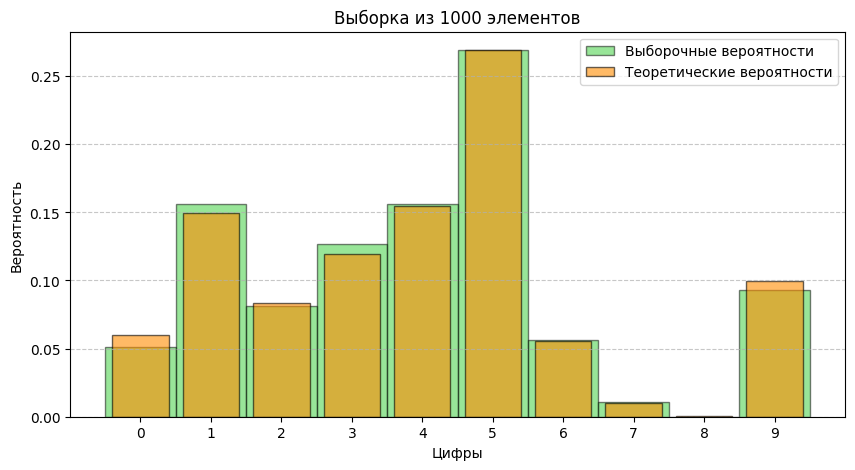

In [8]:
weights = np.array([0.12,0.3,0.167,0.24,0.31,0.54,0.111,0.02,0.001,0.2])
digits = np.arange(10)
probs = weights/weights.sum()
idx = np.argsort(probs)[::-1]
probs_sorted = probs[idx]
digits_sorted = digits[idx]
cum = np.cumsum(probs_sorted)
n = 1000
u = np.random.rand(n)
sample = np.array([digits_sorted[np.searchsorted(cum,val)] for val in u])
unique, counts = np.unique(sample, return_counts=True)
print("Количество каждой цифры в выборке:")
for d,c in zip(unique, counts):
    print(f"Цифра {d}: {c} раз")
plt.figure(figsize=(10,5))
plt.hist(sample, bins=np.arange(-0.5,10.5,1), density=True, alpha=0.5, edgecolor='black', color='limegreen', label='Выборочные вероятности')
plt.bar(digits, probs, alpha=0.6, color='darkorange', edgecolor='black', linewidth=1, label='Теоретические вероятности')
plt.xticks(digits)
plt.title(f"Выборка из {n} элементов")
plt.xlabel("Цифры")
plt.ylabel("Вероятность")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## Задача 5
экспоненциальное распределение методом обратного преобразования

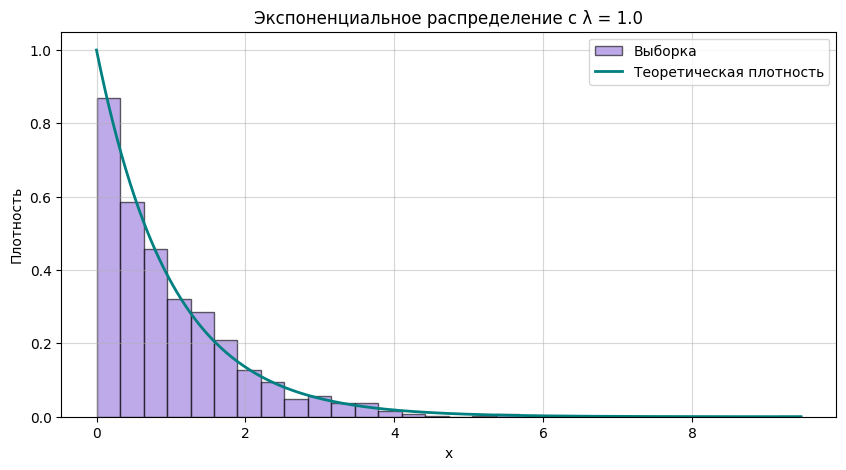

In [9]:
lam = 1.0
n = 1000
u = np.random.rand(n)
x = -np.log(1-u)/lam
plt.figure(figsize=(10,5))
plt.hist(x, bins=30, density=True, alpha=0.6, color='mediumpurple', edgecolor='black', label='Выборка')
xx = np.linspace(0, np.max(x), 500)
plt.plot(xx, lam*np.exp(-lam*xx), color='teal', linewidth=2, label='Теоретическая плотность')
plt.title(f"Экспоненциальное распределение с λ = {lam}")
plt.xlabel("x")
plt.ylabel("Плотность")
plt.legend()
plt.grid(alpha=0.5)
plt.show()

## Задача 6
принятия-отверг для плот-ти e^x·cos²(x) на [-π/2, π/2]

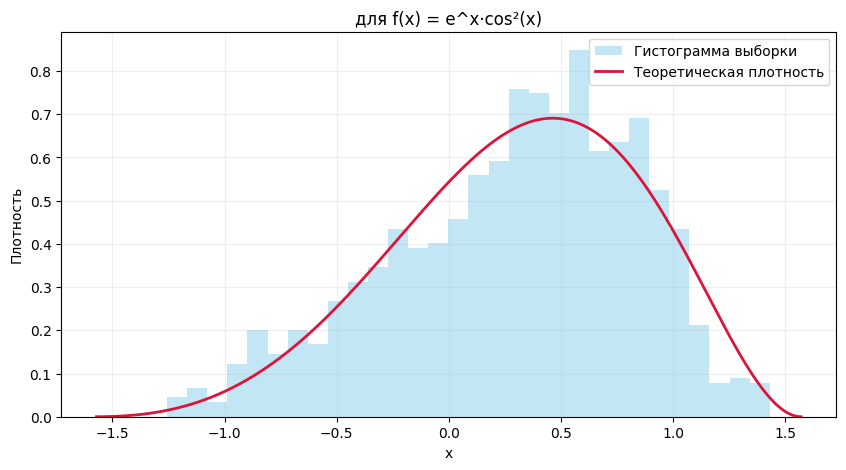

In [11]:
from scipy.optimize import minimize_scalar
from scipy.integrate import quad
def f(x):
    return np.exp(x)*np.cos(x)**2
a,b = -np.pi/2, np.pi/2
opt = minimize_scalar(lambda x: -f(x), bounds=(a,b), method='bounded')
M = f(opt.x)*(b-a)*1.01
def ar_sample(n, a, b, M):
    out = []
    while len(out) < n:
        y = np.random.uniform(a,b)
        u = np.random.rand()
        if u <= f(y)/(M/(b-a)):
            out.append(y)
    return np.array(out)
np.random.seed(42)
smp = ar_sample(1000, a, b, M)
xx = np.linspace(a, b, 500)
Z, _ = quad(f, a, b)
true = f(xx)/Z
plt.figure(figsize=(10,5))
plt.hist(smp, bins=30, density=True, alpha=0.5, color='skyblue', label='Гистограмма выборки')
plt.plot(xx, true, color='crimson', linewidth=2, label='Теоретическая плотность')
plt.title("для f(x) = e^x·cos²(x)")
plt.xlabel("x")
plt.ylabel("Плотность")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Задача 7
равномерное распределение в треугольнике

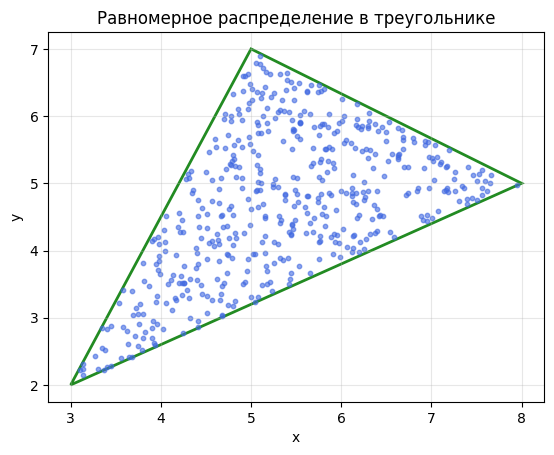

In [12]:
from matplotlib.patches import Polygon
A = np.array([5,7])
B = np.array([3,2])
C = np.array([8,5])
def sample_triangle(n, seed=1):
    np.random.seed(seed)
    u = np.random.rand(n)
    v = np.random.rand(n)
    mask = (u+v > 1)
    u[mask] = 1 - u[mask]
    v[mask] = 1 -v[mask]
    return A + u.reshape(-1,1)*(B-A) + v.reshape(-1,1)*(C-A)
pts = sample_triangle(500, 42)
fig, ax = plt.subplots()
triangle = Polygon([A,B,C], closed=True, fill=False, edgecolor='forestgreen', linewidth=2)
ax.add_patch(triangle)
ax.scatter(pts[:,0], pts[:,1], s=10, color='royalblue', alpha=0.6)
ax.set_title("Равномерное распределение в треугольнике")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(alpha=0.3)
plt.show()

## Задача 8
равномерное распределение внутри единичного круга метод с корнем

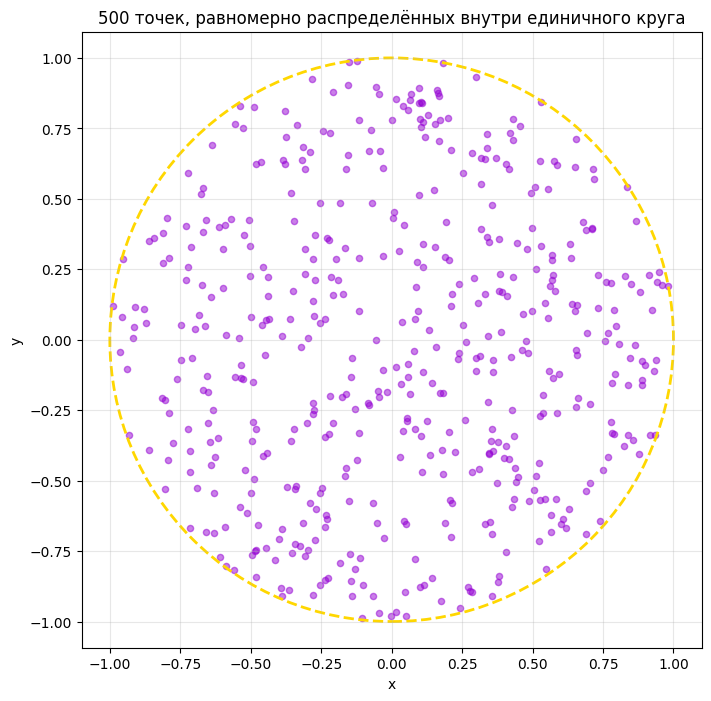

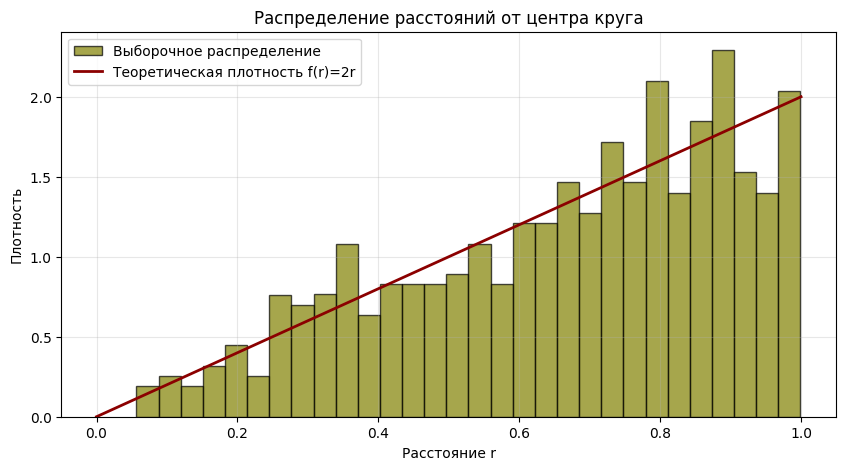

In [13]:
n = 500
theta = 2*np.pi*np.random.rand(n)
r = np.sqrt(np.random.rand(n))
x = r*np.cos(theta)
y = r*np.sin(theta)
plt.figure(figsize=(8,8))
plt.scatter(x, y, alpha=0.5, s=20, color='darkviolet')
plt.gca().add_patch(plt.Circle((0,0), 1, fill=False, color='gold', linestyle='--', linewidth=2))
plt.axis('equal')
plt.title("500 точек, равномерно распределённых внутри единичного круга")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.show()
plt.figure(figsize=(10,5))
plt.hist(r, bins=30, density=True, alpha=0.7, color='olive', edgecolor='black', label='Выборочное распределение')
rr = np.linspace(0,1,100)
plt.plot(rr, 2*rr, color='darkred', linewidth=2, label='Теоретическая плотность f(r)=2r')
plt.title("Распределение расстояний от центра круга")
plt.xlabel("Расстояние r")
plt.ylabel("Плотность")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Задача 9
метод Бокса-Мюллера

In [ ]:
import seaborn as sns
from scipy.linalg import cholesky
def box_muller_polar(n):
    z = np.zeros((n,2))
    for i in range(n):
        while True:
            u = 2*np.random.rand() - 1
            v = 2*np.random.rand() - 1
            s = u*u + v*v
            if 0 < s < 1:
                break
        factor = np.sqrt(-2*np.log(s)/s)
        z[i,0] = u*factor
        z[i,1] = v*factor
    return z

mu = np.array([4,7])
Sigma = np.array([[20,-4],[-4,40]])
n = 1000

Z = box_muller_polar(n)
L = cholesky(Sigma, lower=True)
X = mu + Z @ L.T

print(f"Точное среднее μ: {mu}")
print(f"Выборочное среднее: {np.mean(X, axis=0)}")
print(f"\nТочная ковариационная матрица Σ:\n{Sigma}")
print(f"\nВыборочная ковариационная матрица:\n{np.cov(X, rowvar=False)}")

sns.jointplot(x=X[:,0], y=X[:,1], kind='hex', bins=30, cmap='plasma')
plt.suptitle("Двумерная гистограмма выборки из 1000 точек", y=1.05)
plt.show()

plt.figure(figsize=(10,5))
plt.scatter(X[:,0], X[:,1], alpha=0.5, s=10, color='mediumturquoise')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Выборка из двумерного нормального распределения")
plt.grid(alpha=0.2)
plt.axis('equal')
plt.show()